<a href="https://colab.research.google.com/github/kthanikonda/Privacy-Aware-Computing/blob/main/privacy_doc_2-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install textstat swifter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.3/105.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.4/939.4 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.0 MB/s eta 0:00:00
  Created wheel for swifter: filename=swifter-1.4.0-py3-none-any.whl size=16507 sha256=b747a775c26aeb4184b93060326572f6ab0f820c24c39caab20fca8b3515348c
  Stored in directory: /root/.cache/pip/wheels/ef/7f/bd/9bed48f078f3ee1fa75e0b29b6e0335ce1cb03a38d3443b3a3
Successfully built swifter


In [2]:
import nltk
import spacy
import numpy as np
import textstat
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, wordnet as wn
from nltk import pos_tag
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from wordcloud import WordCloud
from textblob import TextBlob
from google.colab import files
import hashlib
from numpy.random import laplace
import swifter
import multiprocessing

#  STEP 1: File Upload & Reading
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f" Uploaded file: {filename}")
df_squad = pd.read_excel(filename, engine='openpyxl')
df_squad.head()


Saving Squad.xlsx to Squad.xlsx
 Uploaded file: Squad.xlsx


,question
0,To whom did the Virgin Mary allegedly appear i...
1,What is in front of the Notre Dame Main Building?
2,The Basilica of the Sacred heart at Notre Dame...
3,What is the Grotto at Notre Dame?
4,What sits on top of the Main Building at Notre...


In [3]:
#  STEP 2: Download NLTK Resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

# Load NLP & Stopwords
nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words("english"))


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [4]:
import spacy
import random
import pandas as pd

# Load the pre-trained spaCy model
nlp = spacy.load("en_core_web_sm")

# ✅ Named Entity Replacement (Before DP Perturbation)
def replace_named_entities(text):
    """Replaces named entities with generic terms for differential privacy."""
    doc = nlp(text)
    entity_replacements = {
        "PERSON": "A Historical Figure",
        "ORG": "An Established Organization",
        "GPE": "A Recognized Location",
        "DATE": "Some Time Ago",
        "TIME": "Earlier Today",
        "FAC": "A Recognized Building",
        "LOC": "A Specific Location"
    }

    for ent in doc.ents:
        if ent.label_ in entity_replacements:
            text = text.replace(ent.text, entity_replacements[ent.label_])

    return text


#  Apply Named Entity Redaction to your dataset
df_squad["sanitized_question"] = df_squad["question"].apply(replace_named_entities)

#  Display First 5 Rows of the sanitized dataset
print("\nNamed Entity Redaction Completed\n")
for i in range(min(5, len(df_squad))):
    original = df_squad.loc[i, "question"]
    sanitized = df_squad.loc[i, "sanitized_question"]

    print(f"Original Question: {original}")
    print(f"Sanitized Question: {sanitized}")
    print("-" * 80)

# Save the sanitized dataset
sanitized_file_path = "sanitized_squad_fixed.csv"
df_squad.to_csv(sanitized_file_path, index=False)
print(f"Named Entity Redacted Data saved as: {sanitized_file_path}")



Named Entity Redaction Completed

Original Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Sanitized Question: To whom did A Recognized Building allegedly appear in Some Time Ago in A Historical Figure?
--------------------------------------------------------------------------------
Original Question: What is in front of the Notre Dame Main Building?
Sanitized Question: What is in front of A Recognized Building?
--------------------------------------------------------------------------------
Original Question: The Basilica of the Sacred heart at Notre Dame is beside to which structure?
Sanitized Question: The Basilica of the A Historical Figure heart at A Recognized Building is beside to which structure?
--------------------------------------------------------------------------------
Original Question: What is the Grotto at Notre Dame?
Sanitized Question: What is the Grotto at A Recognized Building?
----------------------------------------------------

In [5]:
import spacy
import os
os.system("python -m spacy download en_core_web_md")  # Install in runtime
nlp = spacy.load("en_core_web_md")  # Load after installation


In [6]:


# ✅ Mapping POS Tags to WordNet POS (Universal Mapping for Better Accuracy)
def get_wordnet_pos(treebank_tag):
    """Convert NLTK POS tags to WordNet POS tags for better synonym matching."""
    if treebank_tag.startswith('J'): return wn.ADJ
    elif treebank_tag.startswith('V'): return wn.VERB
    elif treebank_tag.startswith('N'): return wn.NOUN
    elif treebank_tag.startswith('R'): return wn.ADV
    else: return None  # Prevents errors for unknown types

# ✅ Function to Find Valid Synonyms (Ensuring Readability & Perturbation Works)
def get_valid_synonyms(word, wn_pos):
    """Fetches valid synonyms based on word similarity constraints."""
    synonyms = wn.synsets(word, pos=wn_pos) if wn_pos else wn.synsets(word)

    synonym_list = list(set(
        lemma.name() for syn in synonyms for lemma in syn.lemmas()
        if "_" not in lemma.name()  # No multi-word synonyms
        and lemma.name().isalpha()  # No symbols or numbers
        and abs(len(lemma.name()) - len(word)) <= 3  # Keep length similar
        and lemma.name().lower() != word.lower()  # Avoid self-replacement
    ))

    return synonym_list

# ✅ Improved DP Text Perturbation Function (Fixing "amp" & Incorrect Words)
def dp_text_perturbation(text, prob=0.8, epsilon=1.0):
    """
    Applies Differential Privacy perturbation using an improved exponential mechanism.
    Ensures:
    - No incorrect replacements (e.g., `"amp"` artifacts)
    - Correct noun/verb meanings
    - At least one perturbation per sentence
    """
    words = word_tokenize(text)
    pos_tags = pos_tag(words)
    perturbed_text = []

    perturbed_map = {}
    perturbed_count = 0

    for word, tag in pos_tags:
        # 🔹 Keep essential stopwords (is, the, in, at, on, of, etc.)
        if word.lower() in ["is", "the", "in", "at", "on", "of", "did", "be", "to", "and"]:
            perturbed_text.append(word)
            continue

        # 🔹 Higher probability of perturbation (default 80%)
        if random.random() < prob:
            wn_pos = get_wordnet_pos(tag)  # 🔹 Ensure the correct POS tag
            synonym_list = get_valid_synonyms(word, wn_pos)

            if synonym_list:
                scores = np.random.laplace(0, 1 / epsilon, len(synonym_list))
                probabilities = np.exp(epsilon * scores) / np.sum(np.exp(epsilon * scores))
                perturbed_word = np.random.choice(synonym_list, p=probabilities)

                if word not in perturbed_map:
                    perturbed_map[word] = perturbed_word  # Avoid duplicate perturbations

                perturbed_text.append(perturbed_map[word])
                perturbed_count += 1
                continue  # Skip adding the original word

        perturbed_text.append(word)  # 🔹 Keep word if no suitable replacement

    # ✅ If no words were perturbed, force perturbation of one random word
    if perturbed_count == 0 and len(words) > 3:
        idx = random.randint(0, len(words) - 1)
        wn_pos = get_wordnet_pos(pos_tags[idx][1])
        synonym_list = get_valid_synonyms(words[idx], wn_pos)
        if synonym_list:
            words[idx] = random.choice(synonym_list)
        return " ".join(words)

    # ✅ Final text cleanup (removes encoding artifacts like "amp")
    final_text = " ".join(perturbed_text)
    final_text = final_text.replace("amp ", "").replace("  ", " ")  # Removes "amp" artifacts

    return final_text.strip()

# ✅ Apply DP Perturbation to Sanitized Questions
df_squad["dp_perturbation"] = df_squad["sanitized_question"].astype(str).apply(lambda x: dp_text_perturbation(x, epsilon=1.0))

# ✅ Display First 5 Rows
print("\n✅ DP Perturbation with Final Fixes Applied!\n")
for i in range(min(5, len(df_squad))):
    original = df_squad.loc[i, "question"]
    sanitized = df_squad.loc[i, "sanitized_question"]
    perturbed = df_squad.loc[i, "dp_perturbation"]

    print(f"Original Question: {original}")
    print(f"Sanitized Question: {sanitized}")
    print(f"DP Perturbed Question: {perturbed}")
    print("-" * 80)

# ✅ Save Processed Data
dp_perturb_file_path = "dp_squad_final_fixed.csv"
df_squad.to_csv(dp_perturb_file_path, index=False)
print(f"✅ DP Perturbation with Final Fixes Data saved as: {dp_perturb_file_path}")



✅ DP Perturbation with Final Fixes Applied!

Original Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Sanitized Question: To whom did A Recognized Building allegedly appear in Some Time Ago in A Historical Figure?
DP Perturbed Question: To whom did Recognized edifice allegedly seem in roughly metre Ago in A Historical name ?
--------------------------------------------------------------------------------
Original Question: What is in front of the Notre Dame Main Building?
Sanitized Question: What is in front of A Recognized Building?
DP Perturbed Question: What is in forepart of Recognized edifice ?
--------------------------------------------------------------------------------
Original Question: The Basilica of the Sacred heart at Notre Dame is beside to which structure?
Sanitized Question: The Basilica of the A Historical Figure heart at A Recognized Building is beside to which structure?
DP Perturbed Question: The Basilica of the Historical physiq

In [7]:
import multiprocessing
import numpy as np
import swifter
from gensim.models import Word2Vec
from numpy.random import laplace

# ✅ Train Word2Vec Model on DP-Perturbed Text
sentences = [text.split() for text in df_squad['dp_perturbation']]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=multiprocessing.cpu_count())

# ✅ Compute Mean Embedding for OOV Words
if len(w2v_model.wv):
    mean_embedding = np.mean(w2v_model.wv.vectors, axis=0)
else:
    mean_embedding = np.zeros(100)  # Fallback to zero vector if no words are available

# ✅ Function to Get Sentence Embedding with Reduced Laplace Noise
def get_sentence_embedding(text, epsilon=1.5):
    words = text.split()
    word_vectors = [
        w2v_model.wv[word] if word in w2v_model.wv else mean_embedding for word in words
    ]
    if not word_vectors:
        return mean_embedding  # Handle empty sentences

    embedding = np.mean(word_vectors, axis=0)
    noise = laplace(0, 1 / (5 * epsilon), embedding.shape)  # 🔹 **Reduced noise scale**
    return embedding + noise

# ✅ Apply Embeddings in Parallel (Efficiently)
df_squad['original_embedding'] = df_squad['sanitized_question'].astype(str).swifter.apply(
    lambda x: get_sentence_embedding(x, epsilon=1.5)
)
df_squad['dp_embedding'] = df_squad['dp_perturbation'].astype(str).swifter.apply(
    lambda x: get_sentence_embedding(x, epsilon=1.5)
)

# ✅ Display First 5 Rows in Correct Format
print("\n **Sample Sentences: Word Embeddings Before and After DP Perturbation**\n")
for i in range(min(5, len(df_squad))):
    original = df_squad.loc[i, "sanitized_question"]
    perturbed = df_squad.loc[i, "dp_perturbation"]
    original_embedding = df_squad.loc[i, "original_embedding"][:5]  # First 5 dimensions
    dp_embedding = df_squad.loc[i, "dp_embedding"][:5]  # First 5 dimensions

    print(f"Sanitized Sentence: {original}")
    print(f"Perturbed Sentence: {perturbed}")
    print(f"Sanitized Embedding (First 5 Dimensions): {np.round(original_embedding, 8)}")
    print(f"DP-Perturbed Embedding (First 5 Dimensions): {np.round(dp_embedding, 8)}")
    print("-" * 80)

# ✅ Save Processed Data
sanitized_file_path = "sanitized_squad-2.csv"
df_squad.to_csv(sanitized_file_path, index=False)
print(f"✅ Word Embeddings with Laplace Noise Injection Data saved as: {sanitized_file_path}")

dp_perturb_file_path = "dp_squad_final_fixed.csv"
df_squad.to_csv(dp_perturb_file_path, index=False)
print(f"✅ DP Perturbation with Exponential Mechanism Data saved as: {dp_perturb_file_path}")


Pandas Apply:   0%|          | 0/2000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2000 [00:00<?, ?it/s]


 **Sample Sentences: Word Embeddings Before and After DP Perturbation**

Sanitized Sentence: To whom did A Recognized Building allegedly appear in Some Time Ago in A Historical Figure?
Perturbed Sentence: To whom did Recognized edifice allegedly seem in roughly metre Ago in A Historical name ?
Sanitized Embedding (First 5 Dimensions): [-0.1650288   0.39561432  0.1285431   0.23018728 -0.24095784]
DP-Perturbed Embedding (First 5 Dimensions): [-0.23488411  0.66826938  0.30776724  0.16642181 -0.37094259]
--------------------------------------------------------------------------------
Sanitized Sentence: What is in front of A Recognized Building?
Perturbed Sentence: What is in forepart of Recognized edifice ?
Sanitized Embedding (First 5 Dimensions): [-0.22351039  0.52272646  0.21700487  0.45775876 -0.70016345]
DP-Perturbed Embedding (First 5 Dimensions): [-0.23215051  0.42745364  0.16720779  0.3870539  -0.8186705 ]
--------------------------------------------------------------------------

In [8]:
# STEP 8: Sentiment Analysis & Deception Score Calculation
def calculate_sentiment(text):
    return TextBlob(text).sentiment.polarity if text.strip() else 0.0

def calculate_deception_score(text):
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    clarity_score = textstat.flesch_reading_ease(text)
    return (100 - clarity_score) * 0.7 + (vague_word_count * 5) * 0.3

df_squad["sentiment_score"] = df_squad["question"].apply(calculate_sentiment)
df_squad["dp_sentiment_score"] = df_squad["dp_perturbation"].apply(calculate_sentiment)
df_squad["deception_score"] = df_squad["question"].apply(calculate_deception_score)
df_squad["dp_deception_score"] = df_squad["dp_perturbation"].apply(calculate_deception_score)

# Display First 5 Rows of Sentiment & Deception Score
import pandas as pd
from IPython.display import display

print(" Sentiment & Deception Score Calculated")
display(df_squad.head(5))  # Fixed for Google Colab/Jupyter


 Sentiment & Deception Score Calculated


,question,sanitized_question,dp_perturbation,original_embedding,dp_embedding,sentiment_score,dp_sentiment_score,deception_score,dp_deception_score
0,To whom did the Virgin Mary allegedly appear i...,To whom did A Recognized Building allegedly ap...,To whom did Recognized edifice allegedly seem ...,"[-0.16502879673485893, 0.39561431904373723, 0....","[-0.23488410522004682, 0.6682693825407944, 0.3...",-0.100000,-0.066667,23.282,48.391
1,What is in front of the Notre Dame Main Building?,What is in front of A Recognized Building?,What is in forepart of Recognized edifice ?,"[-0.22351038812335428, 0.5227264612011339, 0.2...","[-0.2321505095120327, 0.4274536416251637, 0.16...",0.166667,0.000000,3.381,24.941
2,The Basilica of the Sacred heart at Notre Dame...,The Basilica of the A Historical Figure heart ...,The Basilica of the Historical physique spirit...,"[-0.3445207462855251, 0.48543842079614125, 0.2...","[-0.20097120647830144, 0.3291897548107427, 0.2...",0.000000,0.000000,23.989,54.313
3,What is the Grotto at Notre Dame?,What is the Grotto at A Recognized Building?,What is the grot at Recognized edifice ?,"[-0.11958084932059634, 0.21972115126079386, 0....","[-0.3390337567394038, 0.6347524836861559, 0.07...",0.000000,0.000000,7.175,24.941
4,What sits on top of the Main Building at Notre...,What sits on top of A Recognized Building at A...,What posture on top of Recognized edifice at A...,"[-0.07936765620979999, 0.4175779658660609, 0.1...","[-0.18356453304113707, 0.43526190866857384, 0....",0.333333,0.500000,4.095,39.627


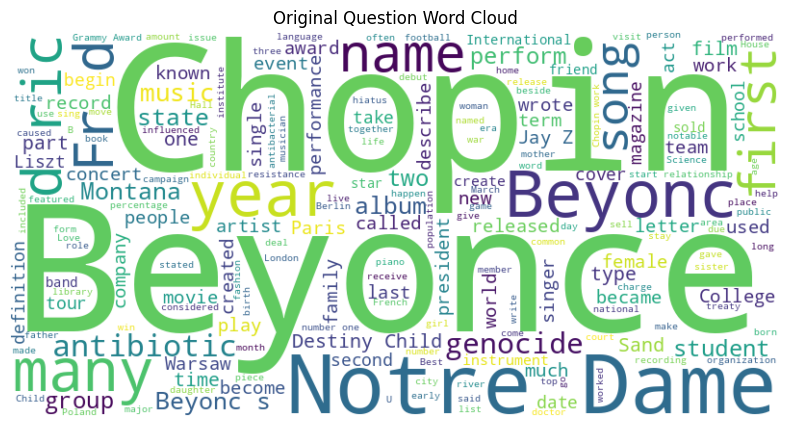

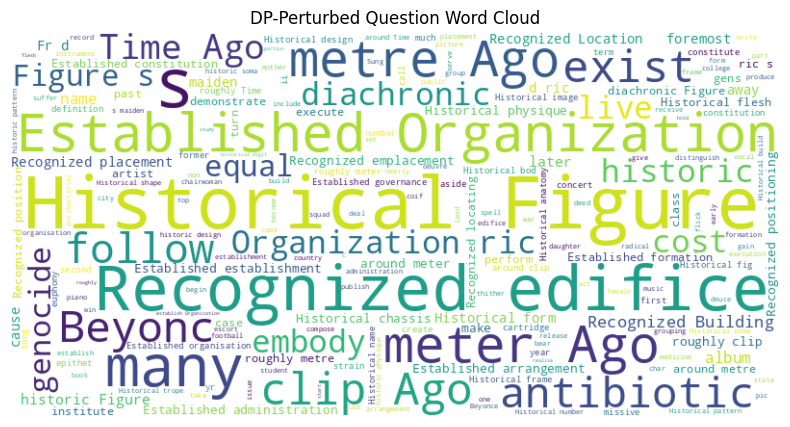

In [9]:
# STEP 6: Word Cloud
wordcloud_original = WordCloud(width=800, height=400, background_color='white').generate(" ".join(df_squad['question'].dropna()))
wordcloud_dp = WordCloud(width=800, height=400, background_color='white').generate(" ".join(df_squad['dp_perturbation'].dropna()))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_original, interpolation='bilinear')
plt.axis("off")
plt.title("Original Question Word Cloud")
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_dp, interpolation='bilinear')
plt.axis("off")
plt.title("DP-Perturbed Question Word Cloud")
plt.show()


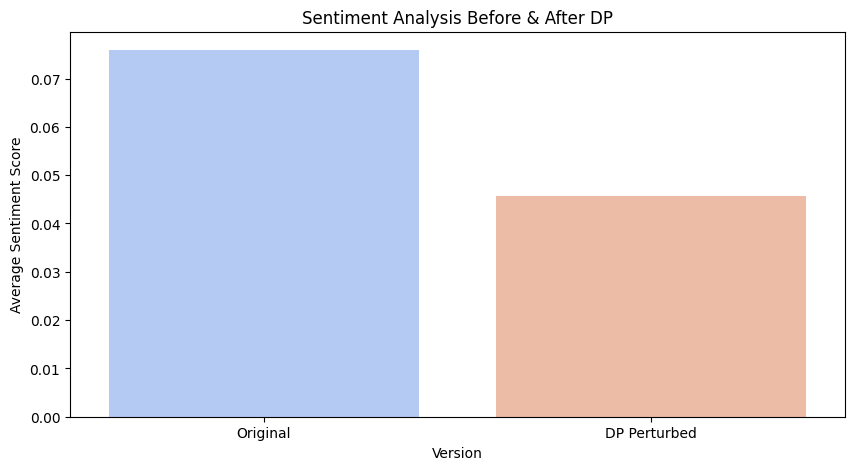

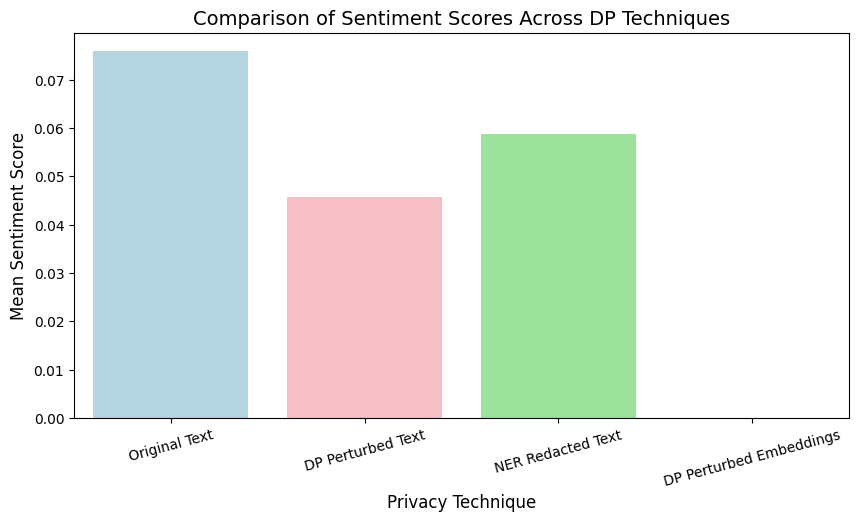

In [10]:
# **STEP 7: Bar Graph for Sentiment & Deception Score Changes**
plt.figure(figsize=(10, 5))
sns.barplot(x=["Original", "DP Perturbed"],
            y=[df_squad["sentiment_score"].mean(), df_squad["dp_sentiment_score"].mean()],
            palette='coolwarm')
plt.xlabel("Version")
plt.ylabel("Average Sentiment Score")
plt.title("Sentiment Analysis Before & After DP")
plt.show()

# Apply Sentiment Analysis with Fix for Embeddings
df_squad["sentiment_score"] = df_squad["question"].apply(calculate_sentiment)
df_squad["dp_sentiment_score"] = df_squad["dp_perturbation"].apply(calculate_sentiment)

# Additional DP Techniques
df_squad["ner_sentiment_score"] = df_squad["sanitized_question"].apply(calculate_sentiment)
df_squad["embedding_sentiment_score"] = df_squad["dp_embedding"].apply(lambda x: calculate_sentiment(" ".join(map(str, x))))

# Bar Chart for Sentiment Score Comparison
techniques = ["Original Text", "DP Perturbed Text", "NER Redacted Text", "DP Perturbed Embeddings"]
scores = [
    df_squad["sentiment_score"].mean(),
    df_squad["dp_sentiment_score"].mean(),
    df_squad["ner_sentiment_score"].mean(),
    df_squad["embedding_sentiment_score"].mean()
]

# Light color palette
light_palette = ["#ADD8E6", "#FFB6C1", "#90EE90", "#DDA0DD"]  # Light blue, pink, mint, lavender

plt.figure(figsize=(10, 5))
sns.barplot(x=techniques, y=scores, palette=light_palette)
plt.xlabel("Privacy Technique", fontsize=12)
plt.ylabel("Mean Sentiment Score", fontsize=12)
plt.title("Comparison of Sentiment Scores Across DP Techniques", fontsize=14)
plt.xticks(rotation=15)  # Rotate x-axis labels for readability
plt.show()


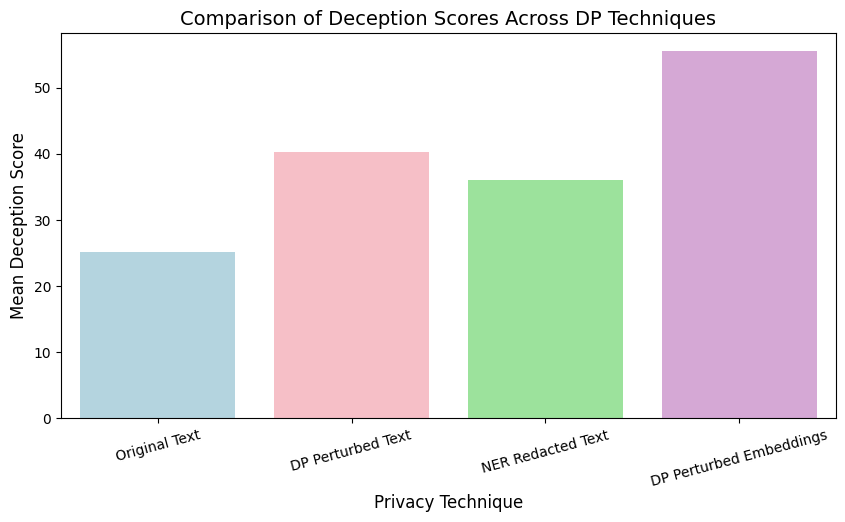

In [11]:
# Additional DP Techniques for Deception Score
df_squad["ner_deception_score"] = df_squad["sanitized_question"].apply(calculate_deception_score)
df_squad["embedding_deception_score"] = df_squad["dp_embedding"].apply(lambda x: calculate_deception_score(" ".join(map(str, x))))

# Bar Chart for Deception Score Comparison
techniques = ["Original Text", "DP Perturbed Text", "NER Redacted Text", "DP Perturbed Embeddings"]
scores = [
    df_squad["deception_score"].mean(),
    df_squad["dp_deception_score"].mean(),
    df_squad["ner_deception_score"].mean(),
    df_squad["embedding_deception_score"].mean()
]

# Light Color Palette for Better Visualization
light_palette = ["#ADD8E6", "#FFB6C1", "#90EE90", "#DDA0DD"]  # Light blue, pink, mint, lavender

plt.figure(figsize=(10, 5))
sns.barplot(x=techniques, y=scores, palette=light_palette)
plt.xlabel("Privacy Technique", fontsize=12)
plt.ylabel("Mean Deception Score", fontsize=12)
plt.title("Comparison of Deception Scores Across DP Techniques", fontsize=14)
plt.xticks(rotation=15)  # Rotate x-axis labels slightly for readability
plt.show()


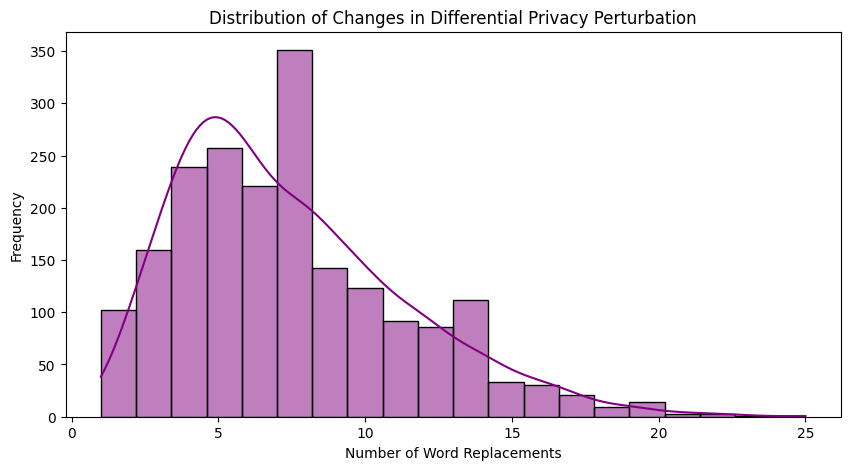

In [12]:
# **STEP 8: Histogram of Changes in Word Perturbation**
df_squad["num_changes"] = df_squad.apply(lambda row: sum(1 for o, p in zip(row["sanitized_question"].split(), row["dp_perturbation"].split()) if o != p), axis=1)

plt.figure(figsize=(10, 5))
sns.histplot(df_squad["num_changes"], bins=20, kde=True, color="purple")
plt.xlabel("Number of Word Replacements")
plt.ylabel("Frequency")
plt.title("Distribution of Changes in Differential Privacy Perturbation")
plt.show()

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


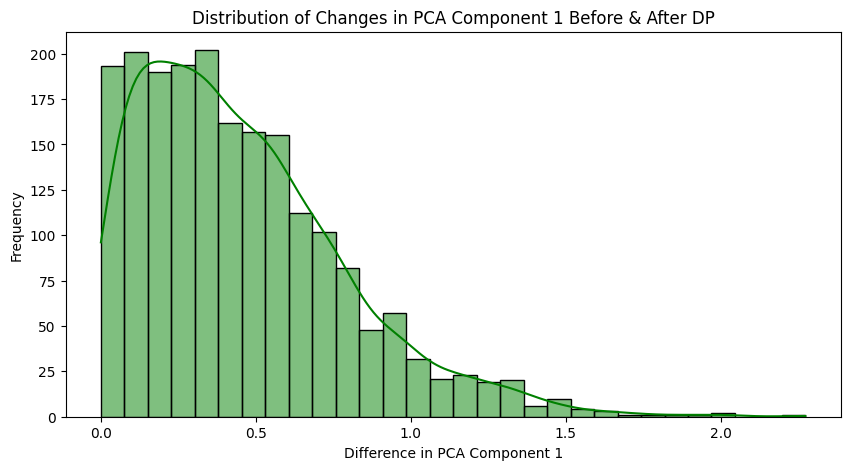

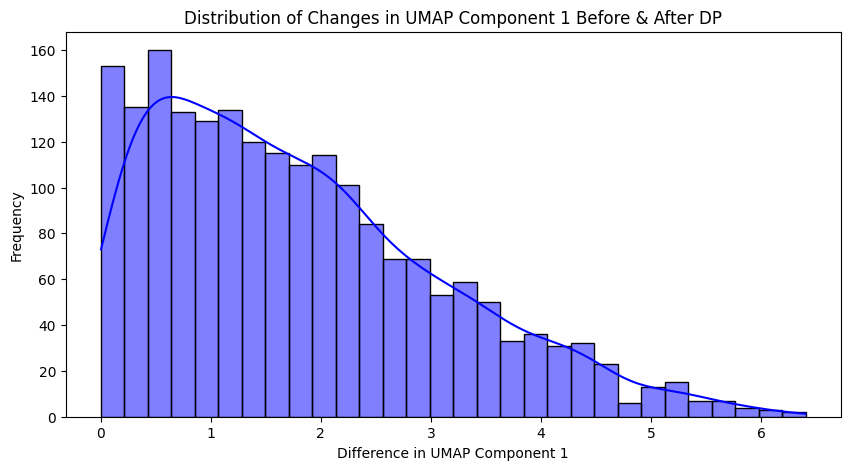

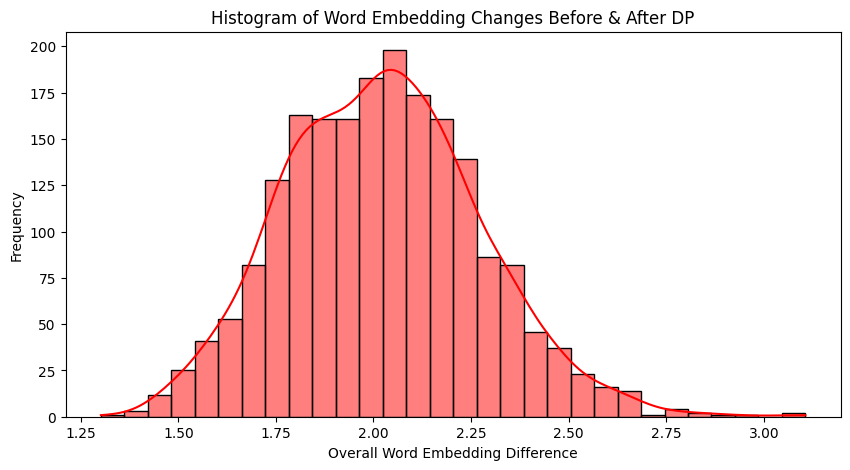

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.decomposition import PCA

# **STEP 1: Ensure PCA is Applied (50 Dimensions)**
pca = PCA(n_components=50, random_state=42)
original_pca = pca.fit_transform(np.vstack(df_squad["original_embedding"].to_numpy()))
dp_pca = pca.transform(np.vstack(df_squad["dp_embedding"].to_numpy()))

# **STEP 2: Apply UMAP for Dimensionality Reduction (2D)**
umap_reducer = umap.UMAP(n_components=2, random_state=42)
original_umap = umap_reducer.fit_transform(original_pca)
dp_umap = umap_reducer.transform(dp_pca)

# **Store UMAP Results in DataFrame**
df_squad['original_embedding_2d_x'] = original_umap[:, 0]
df_squad['original_embedding_2d_y'] = original_umap[:, 1]
df_squad['dp_embedding_2d_x'] = dp_umap[:, 0]
df_squad['dp_embedding_2d_y'] = dp_umap[:, 1]

# **STEP 3: Histogram for Changes in PCA Component 1**
df_squad["pca_component_1_diff"] = np.abs(original_pca[:, 0] - dp_pca[:, 0])

plt.figure(figsize=(10, 5))
sns.histplot(df_squad["pca_component_1_diff"], bins=30, kde=True, color="green")
plt.xlabel("Difference in PCA Component 1")
plt.ylabel("Frequency")
plt.title("Distribution of Changes in PCA Component 1 Before & After DP")
plt.show()

# **STEP 4: Histogram for Changes in UMAP Component 1**
df_squad["umap_component_1_diff"] = np.abs(original_umap[:, 0] - dp_umap[:, 0])

plt.figure(figsize=(10, 5))
sns.histplot(df_squad["umap_component_1_diff"], bins=30, kde=True, color="blue")
plt.xlabel("Difference in UMAP Component 1")
plt.ylabel("Frequency")
plt.title("Distribution of Changes in UMAP Component 1 Before & After DP")
plt.show()

# **STEP 5: Histogram for Overall Word Embedding Differences**
embedding_diff = np.linalg.norm(original_pca - dp_pca, axis=1)

plt.figure(figsize=(10, 5))
sns.histplot(embedding_diff, bins=30, kde=True, color="red")
plt.xlabel("Overall Word Embedding Difference")
plt.ylabel("Frequency")
plt.title("Histogram of Word Embedding Changes Before & After DP")
plt.show()


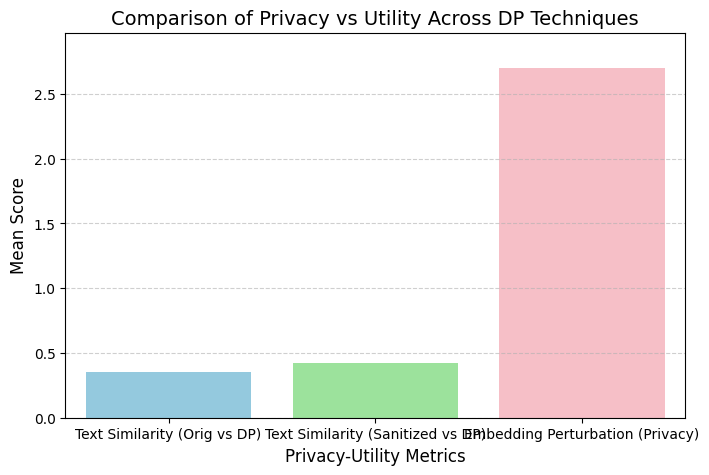

Privacy-Utility Data Table


,Original Text,Sanitized Text,DP Perturbed Text,Text Similarity (Orig vs DP),Text Similarity (Sanitized vs DP),Embedding Difference (Privacy)
0,To whom did the Virgin Mary allegedly appear i...,To whom did A Recognized Building allegedly ap...,To whom did Recognized edifice allegedly seem ...,0.306905,0.552933,2.474183
1,What is in front of the Notre Dame Main Building?,What is in front of A Recognized Building?,What is in forepart of Recognized edifice ?,0.146511,0.273016,2.828597
2,The Basilica of the Sacred heart at Notre Dame...,The Basilica of the A Historical Figure heart ...,The Basilica of the Historical physique spirit...,0.486023,0.570490,2.838429
3,What is the Grotto at Notre Dame?,What is the Grotto at A Recognized Building?,What is the grot at Recognized edifice ?,0.209005,0.291400,3.262785
4,What sits on top of the Main Building at Notre...,What sits on top of A Recognized Building at A...,What posture on top of Recognized edifice at A...,0.264368,0.409106,2.373718


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Compute Text Similarity Using TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df_squad["question"].tolist() +
                                        df_squad["sanitized_question"].tolist() +
                                        df_squad["dp_perturbation"].tolist())

tfidf_vectors = tfidf_matrix.toarray()

# Ensure valid vectors for similarity calculation
n = len(df_squad)

if len(tfidf_vectors) == 3 * n:
    df_squad["text_similarity_original"] = [
        cosine_similarity([tfidf_vectors[i]], [tfidf_vectors[i + 2 * n]])[0, 0]
        for i in range(n)
    ]
    df_squad["text_similarity_sanitized"] = [
        cosine_similarity([tfidf_vectors[i + n]], [tfidf_vectors[i + 2 * n]])[0, 0]
        for i in range(n)
    ]
else:
    df_squad["text_similarity_original"] = np.nan
    df_squad["text_similarity_sanitized"] = np.nan

# Compute Embedding Perturbation Magnitude (Between Original and DP-Perturbed)
df_squad["embedding_difference"] = np.linalg.norm(
    np.array(df_squad["original_embedding"].tolist()) - np.array(df_squad["dp_embedding"].tolist()), axis=1
)

# Create Privacy-Utility DataFrame
privacy_utility_data = pd.DataFrame({
    "Metric": ["Text Similarity (Orig vs DP)", "Text Similarity (Sanitized vs DP)", "Embedding Perturbation (Privacy)"],
    "Score": [
        df_squad["text_similarity_original"].mean(),
        df_squad["text_similarity_sanitized"].mean(),
        df_squad["embedding_difference"].mean()
    ]
})

# **Privacy-Utility Bar Graph**
plt.figure(figsize=(8, 5))
sns.barplot(x="Metric", y="Score", data=privacy_utility_data, palette=["skyblue", "lightgreen", "lightpink"])

# Labels & Title
plt.xlabel("Privacy-Utility Metrics", fontsize=12)
plt.ylabel("Mean Score", fontsize=12)
plt.title("Comparison of Privacy vs Utility Across DP Techniques", fontsize=14)

# Grid for Readability
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Adjust Y-Axis Limits Dynamically
plt.ylim(0, max(privacy_utility_data["Score"]) * 1.1)

plt.show()

# ✅ Create a DataFrame for Display
privacy_utility_df = df_squad[["question", "sanitized_question", "dp_perturbation",
                               "text_similarity_original", "text_similarity_sanitized",
                               "embedding_difference"]].copy()

# ✅ Rename Columns for Better Readability
privacy_utility_df.columns = ["Original Text", "Sanitized Text", "DP Perturbed Text",
                              "Text Similarity (Orig vs DP)", "Text Similarity (Sanitized vs DP)",
                              "Embedding Difference (Privacy)"]

# Display First 5 Rows
import pandas as pd
from IPython.display import display

print("Privacy-Utility Data Table")
display(privacy_utility_df.head(5))  # Fixed for Google Colab/Jupyter


In [15]:
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# ✅ Ensure required columns exist or compute them
required_columns = ["question", "sanitized_question", "dp_perturbation", "text_similarity", "embedding_difference"]

# ✅ If text similarity is missing, compute it
if "text_similarity" not in df_squad.columns:
    print("⚠️ Computing Text Similarity...")
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(df_squad["sanitized_question"].tolist() + df_squad["dp_perturbation"].tolist())
    tfidf_vectors = tfidf_matrix.toarray()

    if len(tfidf_vectors) == 2 * len(df_squad):
        df_squad["text_similarity"] = [
            cosine_similarity([tfidf_vectors[i]], [tfidf_vectors[i + len(df_squad)]])[0, 0]
            for i in range(len(df_squad))
        ]
    else:
        df_squad["text_similarity"] = np.nan

# ✅ If embedding difference is missing, compute it
if "embedding_difference" not in df_squad.columns:
    print("⚠️ Computing Embedding Difference...")
    df_squad["embedding_difference"] = np.linalg.norm(
        np.array(df_squad["original_embedding"].tolist()) - np.array(df_squad["dp_embedding"].tolist()), axis=1
    )

# ✅ Ensure all required columns are present before proceeding
missing_cols = [col for col in required_columns if col not in df_squad.columns]

if not missing_cols:
    # ✅ Create Privacy-Utility DataFrame
    privacy_utility_df = df_squad[required_columns].copy()

    # ✅ Rename Columns for Readability
    privacy_utility_df.columns = [
        "Original Question",
        "Sanitized Question",
        "DP Perturbed Question",
        "Text Similarity (Utility)",
        "Embedding Difference (Privacy)"
    ]

    # ✅ Display First 5 Rows with Detailed Output
    print("\n✅ DP Perturbation with Exponential Mechanism Applied!\n")

    for i in range(min(5, len(privacy_utility_df))):  # Show first 5 rows correctly
        original = privacy_utility_df.iloc[i]["Original Question"]
        sanitized = privacy_utility_df.iloc[i]["Sanitized Question"]
        perturbed = privacy_utility_df.iloc[i]["DP Perturbed Question"]
        text_sim = privacy_utility_df.iloc[i]["Text Similarity (Utility)"]
        embed_diff = privacy_utility_df.iloc[i]["Embedding Difference (Privacy)"]

        print(f"Original Question: {original}")
        print(f"Sanitized Question: {sanitized}")
        print(f"DP Perturbed Question: {perturbed}")
        print(f"Text Similarity: {text_sim:.4f}")
        print(f"Embedding Difference: {embed_diff:.4f}")
        print("-" * 80)

    # ✅ Save Final Privacy-Utility Data
    dp_perturb_file_path = "dp_squad_final_fixed.csv"
    df_squad.to_csv(dp_perturb_file_path, index=False)
    print(f"\n✅ DP Perturbation with Exponential Mechanism Data saved as: {dp_perturb_file_path}")

    # ✅ Display Privacy-Utility Data Table
    print("\n📊 Privacy-Utility Data Table")
    display(privacy_utility_df.head(5))

else:
    print(f"\n❌ Error: The following required columns are missing from `df_squad`: {missing_cols}")


⚠️ Computing Text Similarity...

✅ DP Perturbation with Exponential Mechanism Applied!

Original Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Sanitized Question: To whom did A Recognized Building allegedly appear in Some Time Ago in A Historical Figure?
DP Perturbed Question: To whom did Recognized edifice allegedly seem in roughly metre Ago in A Historical name ?
Text Similarity: 0.5664
Embedding Difference: 2.4742
--------------------------------------------------------------------------------
Original Question: What is in front of the Notre Dame Main Building?
Sanitized Question: What is in front of A Recognized Building?
DP Perturbed Question: What is in forepart of Recognized edifice ?
Text Similarity: 0.2736
Embedding Difference: 2.8286
--------------------------------------------------------------------------------
Original Question: The Basilica of the Sacred heart at Notre Dame is beside to which structure?
Sanitized Question: The Basilica 

,Original Question,Sanitized Question,DP Perturbed Question,Text Similarity (Utility),Embedding Difference (Privacy)
0,To whom did the Virgin Mary allegedly appear i...,To whom did A Recognized Building allegedly ap...,To whom did Recognized edifice allegedly seem ...,0.566446,2.474183
1,What is in front of the Notre Dame Main Building?,What is in front of A Recognized Building?,What is in forepart of Recognized edifice ?,0.273583,2.828597
2,The Basilica of the Sacred heart at Notre Dame...,The Basilica of the A Historical Figure heart ...,The Basilica of the Historical physique spirit...,0.578648,2.838429
3,What is the Grotto at Notre Dame?,What is the Grotto at A Recognized Building?,What is the grot at Recognized edifice ?,0.293078,3.262785
4,What sits on top of the Main Building at Notre...,What sits on top of A Recognized Building at A...,What posture on top of Recognized edifice at A...,0.415768,2.373718


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Pandas Apply:   0%|          | 0/2000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2000 [00:00<?, ?it/s]


📊 Lexical Diversity & Change Analysis:

       lexical_diversity_retained_ratio  lexical_diversity_jaccard_change  \
count                       2000.000000                       2000.000000   
mean                           0.634330                          0.510954   
std                            0.120919                          0.135392   
min                            0.250000                          0.000000   
25%                            0.555556                          0.434783   
50%                            0.636364                          0.526316   
75%                            0.714286                          0.600000   
max                            1.000000                          0.846154   

       lexical_change_score  
count           2000.000000  
mean               0.568161  
std                0.254615  
min                0.000000  
25%                0.333333  
50%                0.555556  
75%                0.800000  
max                1.0000

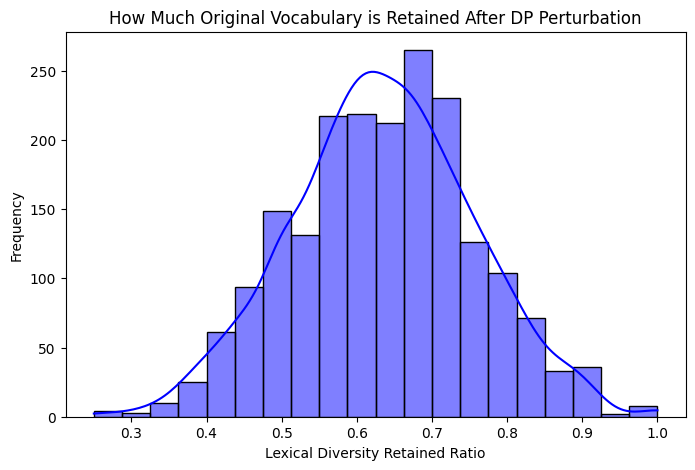


🔍 Sample Lexical Diversity & Changes:

Original: To whom did A Recognized Building allegedly appear in Some Time Ago in A Historical Figure?
DP Perturbed: To whom did Recognized edifice allegedly seem in roughly metre Ago in A Historical name ?
Lexical Diversity Retained Ratio: 0.6667
Lexical Diversity Change (Jaccard Distance): 0.5000
Lexical Change Score: 0.8235
--------------------------------------------------
Original: What is in front of A Recognized Building?
DP Perturbed: What is in forepart of Recognized edifice ?
Lexical Diversity Retained Ratio: 0.6667
Lexical Diversity Change (Jaccard Distance): 0.4545
Lexical Change Score: 0.5556
--------------------------------------------------
Original: The Basilica of the A Historical Figure heart at A Recognized Building is beside to which structure?
DP Perturbed: The Basilica of the Historical physique spirit at Recognized edifice is beside to which construction ?
Lexical Diversity Retained Ratio: 0.6875
Lexical Diversity Change (Ja

In [16]:
import numpy as np
import nltk
import swifter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize

# ✅ Ensure NLTK Resources Are Available
nltk.download('punkt')

# ✅ New: Compute the Proportion of Retained Unique Words
def lexical_diversity_adjusted(original_text, perturbed_text):
    original_words = set(word_tokenize(str(original_text).lower()))
    perturbed_words = set(word_tokenize(str(perturbed_text).lower()))

    if len(original_words) == 0:
        return 0  # Avoid division errors

    retained_words = len(original_words & perturbed_words) / len(original_words)
    return retained_words  # Higher means fewer changes

# ✅ Compute Jaccard Similarity for Lexical Diversity Change
def lexical_diversity_change(original_text, perturbed_text):
    original_words = set(word_tokenize(str(original_text).lower()))
    perturbed_words = set(word_tokenize(str(perturbed_text).lower()))

    if len(original_words) == 0:
        return 0  # Avoid division errors

    jaccard_similarity = len(original_words & perturbed_words) / len(original_words | perturbed_words)
    return 1 - jaccard_similarity  # More change → Higher value

# ✅ Compute Lexical Change Score (word position changes)
def lexical_change_score(original_text, perturbed_text):
    original_words = word_tokenize(str(original_text).lower())
    perturbed_words = word_tokenize(str(perturbed_text).lower())

    if len(original_words) == 0:
        return 0  # Avoid division errors if text is empty

    unchanged_count = sum(1 for o, p in zip(original_words, perturbed_words) if o == p)
    return 1 - (unchanged_count / max(len(original_words), 1))  # More change → Higher value

# ✅ Apply to DataFrame 🚀
df_squad["lexical_diversity_retained_ratio"] = df_squad.swifter.apply(
    lambda row: lexical_diversity_adjusted(row["sanitized_question"], row["dp_perturbation"]), axis=1
)

df_squad["lexical_diversity_jaccard_change"] = df_squad.swifter.apply(
    lambda row: lexical_diversity_change(row["sanitized_question"], row["dp_perturbation"]), axis=1
)

df_squad["lexical_change_score"] = df_squad.swifter.apply(
    lambda row: lexical_change_score(row["sanitized_question"], row["dp_perturbation"]), axis=1
)

# ✅ Display Summary Statistics
print("\n📊 Lexical Diversity & Change Analysis:\n")
print(df_squad[[
    "lexical_diversity_retained_ratio",
    "lexical_diversity_jaccard_change",
    "lexical_change_score"
]].describe())

# ✅ Visualize Lexical Diversity Retention
plt.figure(figsize=(8, 5))
sns.histplot(df_squad["lexical_diversity_retained_ratio"], bins=20, kde=True, color="blue")
plt.xlabel("Lexical Diversity Retained Ratio")
plt.ylabel("Frequency")
plt.title("How Much Original Vocabulary is Retained After DP Perturbation")
plt.show()

# ✅ Sample Before vs. After Analysis (Fixed)
print("\n🔍 Sample Lexical Diversity & Changes:\n")
for i in range(min(10, len(df_squad))):
    original = df_squad.iloc[i]["sanitized_question"]
    perturbed = df_squad.iloc[i]["dp_perturbation"]
    retained_ratio = df_squad.iloc[i]["lexical_diversity_retained_ratio"]
    jaccard_change = df_squad.iloc[i]["lexical_diversity_jaccard_change"]
    lexical_change = df_squad.iloc[i]["lexical_change_score"]

    print(f"Original: {original}")
    print(f"DP Perturbed: {perturbed}")
    print(f"Lexical Diversity Retained Ratio: {retained_ratio:.4f}")
    print(f"Lexical Diversity Change (Jaccard Distance): {jaccard_change:.4f}")
    print(f"Lexical Change Score: {lexical_change:.4f}")
    print("-" * 50)


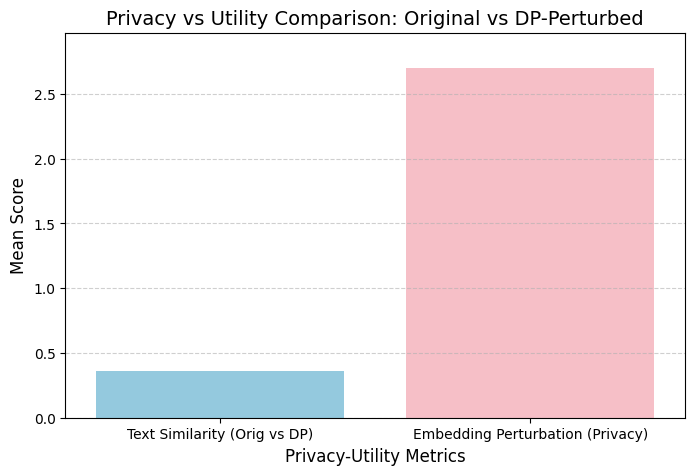

Privacy-Utility Data Table


,Original Text,DP Perturbed Text,Text Similarity (Orig vs DP),Embedding Difference (Privacy)
0,To whom did the Virgin Mary allegedly appear i...,To whom did Recognized edifice allegedly seem ...,0.319013,2.474183
1,What is in front of the Notre Dame Main Building?,What is in forepart of Recognized edifice ?,0.149933,2.828597
2,The Basilica of the Sacred heart at Notre Dame...,The Basilica of the Historical physique spirit...,0.493373,2.838429
3,What is the Grotto at Notre Dame?,What is the grot at Recognized edifice ?,0.219138,3.262785
4,What sits on top of the Main Building at Notre...,What posture on top of Recognized edifice at A...,0.269209,2.373718


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Compute Text Similarity Using TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df_squad["question"].tolist() + df_squad["dp_perturbation"].tolist())
tfidf_vectors = tfidf_matrix.toarray()

# Ensure valid vectors for similarity calculation
n = len(df_squad)

if len(tfidf_vectors) == 2 * n:
    df_squad["text_similarity_original"] = [
        cosine_similarity([tfidf_vectors[i]], [tfidf_vectors[i + n]])[0, 0]
        for i in range(n)
    ]
else:
    df_squad["text_similarity_original"] = np.nan

# Compute Embedding Perturbation Magnitude (Between Original and DP-Perturbed)
df_squad["embedding_difference"] = np.linalg.norm(
    np.array(df_squad["original_embedding"].tolist()) - np.array(df_squad["dp_embedding"].tolist()), axis=1
)

# Create Privacy-Utility DataFrame
privacy_utility_data = pd.DataFrame({
    "Metric": ["Text Similarity (Orig vs DP)", "Embedding Perturbation (Privacy)"],
    "Score": [
        df_squad["text_similarity_original"].mean(),
        df_squad["embedding_difference"].mean()
    ]
})

# **Privacy-Utility Bar Graph (Original vs. DP-Perturbed)**
plt.figure(figsize=(8, 5))
sns.barplot(x="Metric", y="Score", data=privacy_utility_data, palette=["skyblue", "lightpink"])

# Labels & Title
plt.xlabel("Privacy-Utility Metrics", fontsize=12)
plt.ylabel("Mean Score", fontsize=12)
plt.title("Privacy vs Utility Comparison: Original vs DP-Perturbed", fontsize=14)

# Grid for Readability
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Adjust Y-Axis Limits Dynamically
plt.ylim(0, max(privacy_utility_data["Score"]) * 1.1)

plt.show()

# ✅ Create a DataFrame for Display
privacy_utility_df = df_squad[["question", "dp_perturbation",
                               "text_similarity_original", "embedding_difference"]].copy()

# ✅ Rename Columns for Better Readability
privacy_utility_df.columns = ["Original Text", "DP Perturbed Text",
                              "Text Similarity (Orig vs DP)", "Embedding Difference (Privacy)"]

# Display First 5 Rows
import pandas as pd
from IPython.display import display

print("Privacy-Utility Data Table")
display(privacy_utility_df.head(5))  # Fixed for Google Colab/Jupyter
